In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
# for run in run_list:
# 		MUSEdata      = fits.open(gal+‘/structDis/inputData/’+gal+run+‘expV5.fits’)
# 		waveData      = np.arange(MUSEdata[1].header[‘CRVAL3’], MUSEdata[1].header[‘CRVAL3’]+MUSEdata[1].header[‘NAXIS3’]*MUSEdata[1].header[‘CD3_3’], MUSEdata[1].header[‘CD3_3’])
# 		fluxData      = MUSEdata[1].data
	
# 		fluxWave      = fluxData[find_nearest(waveData,4500):find_nearest(waveData,6500), :, :]
# 		fluxtempV     = np.nansum(fluxWave*1e-20, axis=0)
# 		lumdata       = (fluxtempV*(4*np.pi*(dl_cm)**2))/(5.66e32)
	
# 	# ==================================================================================================================
	
# 		table_hdu     = fits.open(gal+‘/structDis/‘+pathway+“/”+gal+run+‘-V5/‘+gal+run+‘-V5_table.fits’) #ID, BINID, X, Y, FLUX, SNR, XBIN, YBIN, SNRBIN, NSPAX
# 		sfh_hdu       = fits.open(gal+‘/structDis/‘+pathway+“/”+gal+run+‘-V5/‘+gal+run+‘-V5_sfh.fits’) #AGE, METAL, ALPHA
# 		weights_hdu   = fits.open(gal+‘/structDis/‘+pathway+“/”+gal+run+‘-V5/‘+gal+run+‘-V5_sfh-weights.fits’) #[1] WEIGHTS, [2] GRID: LOGAGE, METAL, ALPHA
	
# 	# ==================================================================================================================
	
# 		idx_inside  = np.where( table_hdu[1].data.BIN_ID >= 0        )[0]
# 		nbins         = weights_hdu[1].data.shape[0]
# 		binNum_long = np.array( table_hdu[1].data.BIN_ID[idx_inside] )
# 		nAges         = weights_hdu[0].header[‘NAGES’]
	
# 		nMetal        = weights_hdu[0].header[‘NMETAL’]
# 		nAlpha        = weights_hdu[0].header[‘NALPHA’]
# 		Weights       = np.reshape(np.array(weights_hdu[1].data.WEIGHTS), (nbins,nAges,nMetal,nAlpha) )
# 		Weights       = np.transpose(Weights, (0,2,1,3)) #Weights[bins,metal,age,alpha]
	
# 		_, idxShortToLong = np.unique( np.abs(binNum_long), return_inverse=True )
	
# 		X             = np.array( table_hdu[1].data.X[idx_inside]      )
# 		Y             = np.array( table_hdu[1].data.Y[idx_inside]      )
# 		XBIN          = np.array( table_hdu[1].data.XBIN[idx_inside]      )
# 		YBIN          = np.array( table_hdu[1].data.YBIN[idx_inside]      )
# 		pixelsize     = table_hdu[0].header[‘PIXSIZE’]
# 		metals        = np.unique(weights_hdu[2].data.METAL)
# 		age           = np.power(10, np.unique(weights_hdu[2].data.LOGAGE))
# 		alphas        = np.unique( weights_hdu[2].data.ALPHA )
	
# 	# ==================================================================================================================
	
# 		for a in range(nAges):
# 			for m in range(nMetal):
# 				idx_molZero      = np.where( np.logical_and( MtoL_alphaZero[:,3] == np.round(age[a],2), MtoL_alphaZero[:,2] == np.round(metals[m],2) ) )[0]
# 				idx_molZeropFour = np.where( np.logical_and( MtoL_alphaZeropFour[:,3] == np.round(age[a],2), MtoL_alphaZeropFour[:,2] == np.round(metals[m],2) ) )[0]
			
# 				Weights[:,m,a,0] = Weights[:,m,a,0] * MtoL_alphaZero[idx_molZero,9]  # Apply M(*+remn)/L
# 				Weights[:,m,a,1] = Weights[:,m,a,1] * MtoL_alphaZeropFour[idx_molZeropFour,9]  # Apply M(*+remn)/L
	
# 		for bin in np.arange(0,len(idx_inside)): ## change index for median // mean // sum
# 			sfh_list_V5[run].append(lumdata.flatten()[idx_inside][bin]*np.sum(Weights,axis=(1,3))[idxShortToLong][bin])

In [20]:
# Reading weights

ngc613_weights_path_miles = ('../../data_products/NGC0613_DATACUBE_FINAL_clean/MilesAgeMhAlpha/'
                             'ppxf/weights.fits')

with fits.open(ngc613_weights_path_miles) as hdul:
    hdul.info()
    weights_miles = hdul[0].data

# age
# ngc1097_weights_path_miles = ('../../data_products/NGC1097_DATACUBE_FINAL_clean/MilesAgeMhAlpha_1/ppxf/average_age.fits')

# with fits.open(ngc1097_weights_path_miles) as hdul:
#     hdul.info()
#     weights_miles = hdul[0].data

# Reading metadata

ngc613_metadata_path_miles = ('../../data_products/NGC0613_DATACUBE_FINAL_clean/MilesAgeMhAlpha'
                              '/ppxf/metadata.json')

with open(ngc613_metadata_path_miles) as fp:
    meta = json.load(fp)

Filename: ../../data_products/NGC0613_DATACUBE_FINAL_clean/MilesAgeMhAlpha/ppxf/weights.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (329, 317, 150)   float32   


In [27]:
# import os
ngc613_muse_path = '../../data/NGC613/Muse/NGC0613_DATACUBE_FINAL_clean.fits.gz'
# os.system(f'fitsheader {ngc1097_muse_path} hdu=1')

In [28]:
with fits.open(ngc613_muse_path, memmap=True) as hdul:
    spec_flux = hdul[1].data
    hdr = hdul[1].header
    wave_obs =  hdr['CRVAL3'] + np.arange(hdr['NAXIS3']) * hdr['CD3_3']
    bunit = 1e-20

In [29]:
    # BUNIT   = '10**(-20)*erg/s/cm**2/Angstrom'                                      
    # CD3_3   =                 1.25                                                  
    # CRPIX3  =                   1.                                                  
    # CRVAL3  =      4750.3232421875
    

In [30]:
%matplotlib widget

mh_range = np.array(meta['model']['mh_range'])
# print(mh_range.shape)

age_range = np.array(meta['model']['age_range'])
# print(age_range.shape)

reg_dim = np.array(meta['model']['reg_dim'])
# print(reg_dim)

position = (208, 155) # (y, x)

# meta['obs']['original_signal']

y_full = meta['obs']['y_full']
x_full = meta['obs']['x_full']

# fig, ax = plt.subplots()
# ax.scatter(meta['obs']['y_full'], meta['obs']['x_full'], c=meta['obs']['original_signal'])
# ax.scatter(x_full[155], y_full[208], marker ='*', c='r')
# fig, ax = plt.subplots()
# ax.imshow(origin='lower')

In [31]:
w = weights_miles[slice(None), position[0], position[1]].reshape(reg_dim)

In [32]:
flux = np.nansum(spec_flux[slice(None), position[0], position[1]] * bunit * 1.25)
flux

9.796261e-15

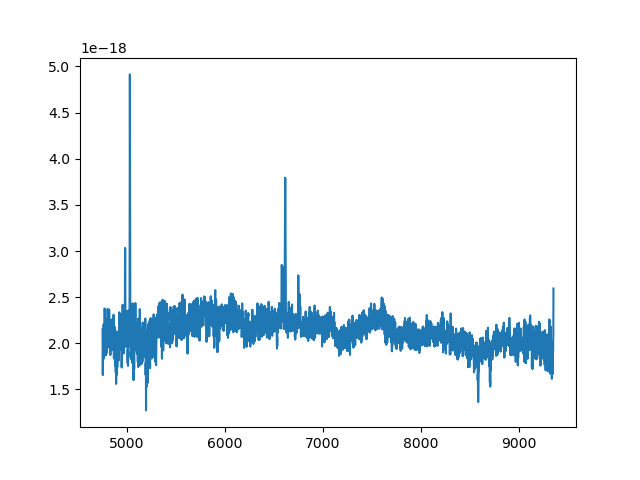

In [33]:
fig, ax = plt.subplots()
ax.plot(wave_obs, spec_flux[slice(None), position[0], position[1]] * bunit)

In [34]:
dist_mpc = 14.5 * 1e6
dist_cm = dist_mpc * 3.0856775814914e18
# print(rf'distance {dist_cm: .2e} cm')

lum = 4*np.pi*dist_cm**2*flux
lum_o = lum / (3.846*10e33)
lum_o
print(rf'L ~{lum_o: .2f} Lo')

L ~ 6407.64 Lo


(25, 6, 1)

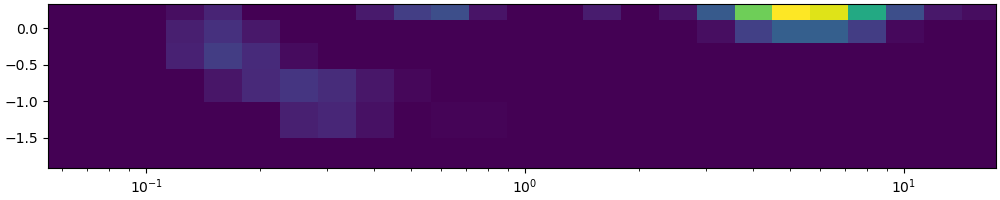

In [115]:
# fig, ax = plt.subplots()
# ax.imshow(w/w.sum())

fig, ax = plt.subplots(figsize=(10,2), constrained_layout=True)
ax.pcolormesh(age_range, mh_range, w[:,:,0].T/w.sum())
ax.set_xscale('log')

w.shape

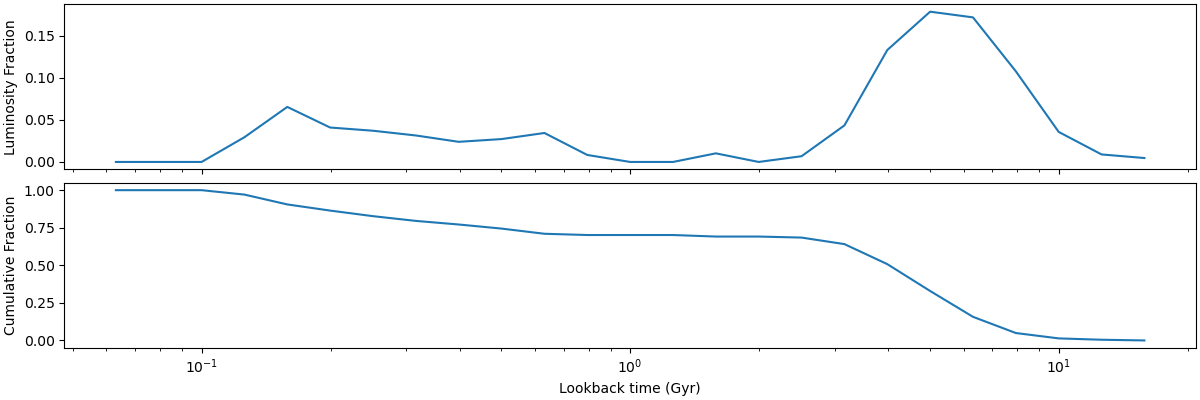

In [110]:
wl_sum_ages = np.nansum(w/w.sum(), 1)

fig, ax = plt.subplots(2, 1, figsize=(12,4), constrained_layout=True, sharex=True)
ax[0].plot(age_range, wl_sum_ages)
# ax[0].set_xlabel('Lookback time (Gyr)')
ax[0].set_ylabel('Luminosity Fraction')
# ax[0].invert_xaxis()
ax[0].set_xscale('log')

ax[1].plot(age_range, 1-wl_sum_ages.cumsum())
ax[1].set_xlabel('Lookback time (Gyr)')
ax[1].set_ylabel('Cumulative Fraction')
# ax[1].invert_xaxis()
ax[1].set_xscale('log')

In [111]:
# path_ml_miles = '../../data/models/UBBVRIJHK_kb_iTp0.00.MAG'
path_ml_miles = '../../data/models/UBBVRIJHK_un_iPp0.00.MAG'

ml_miles = pd.read_table(path_ml_miles, sep=' ')
ml_miles = ml_miles[ml_miles.model.str.contains('Eun1.3')]
ml_miles


,model,mu,Z,Age,M(*+remn),U_Buser,B2_Buser,B3_Buser,V_Buser,R_Cousins,...,K_Johnson,ML(U_Buser),ML(B2_Buser),ML(B3_Buser),ML(V_Buser),ML(R_Cousins),ML(I_Cousins),ML(J_Johnson),ML(H_Bessell),ML(K_Johnson)
1400,Eun1.30Zm2.32T00.0631_iPp0.00_baseFe.fits,1.3,-2.32,0.0631,0.8578,2.27851,2.93159,2.92361,3.05950,-99.00000,...,-99.00000,0.04025,0.08504,0.08442,0.16951,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
1401,Eun1.30Zm2.32T00.0708_iPp0.00_baseFe.fits,1.3,-2.32,0.0708,0.8578,2.38074,2.99697,2.98954,3.11157,-99.00000,...,-99.00000,0.04423,0.09032,0.08970,0.17783,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
1402,Eun1.30Zm2.32T00.0794_iPp0.00_baseFe.fits,1.3,-2.32,0.0794,0.8535,2.46883,3.05496,3.04800,3.15864,-99.00000,...,-99.00000,0.04772,0.09480,0.09419,0.18478,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
1403,Eun1.30Zm2.32T00.0891_iPp0.00_baseFe.fits,1.3,-2.32,0.0891,0.8491,2.55562,3.11228,3.10577,3.20450,-99.00000,...,-99.00000,0.05143,0.09942,0.09883,0.19176,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
1404,Eun1.30Zm2.32T00.1000_iPp0.00_baseFe.fits,1.3,-2.32,0.1000,0.8403,2.65209,3.18453,3.17843,3.26636,-99.00000,...,-99.00000,0.05563,0.10516,0.10457,0.20090,-99.00000,-99.00000,-99.00000,-99.00000,-99.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,Eun1.30Zp0.22T11.2202_iPp0.00_baseFe.fits,1.3,0.22,11.2202,0.7178,9.07028,8.31766,8.36005,7.34110,6.73027,...,4.09749,17.54350,10.15473,10.55902,7.31883,5.81448,4.13796,2.37470,1.63269,1.45011
1746,Eun1.30Zp0.22T12.5893_iPp0.00_baseFe.fits,1.3,0.22,12.5893,0.7159,9.21191,8.43095,8.47411,7.44035,6.82142,...,4.16099,19.93491,11.24172,11.69755,7.99817,6.30697,4.45251,2.51514,1.72619,1.53337
1747,Eun1.30Zp0.22T14.1254_iPp0.00_baseFe.fits,1.3,0.22,14.1254,0.7140,9.34418,8.54123,8.58506,7.53824,6.91102,...,4.24445,22.45791,12.41055,12.92179,8.72964,6.83137,4.79314,2.70539,1.85896,1.65149
1748,Eun1.30Zp0.22T15.8489_iPp0.00_baseFe.fits,1.3,0.22,15.8489,0.7123,9.47820,8.65781,8.70209,7.64536,7.01097,...,4.31256,25.34788,13.78442,14.35818,9.61188,7.47227,5.18802,2.86605,1.97499,1.75424


In [129]:
# ml_miles['Age'].isin(age_range)
print(ml_miles['Age'].unique())
# print(age_range)
# ml_miles =  ml_miles[a]

# b = ml_miles['Z'].isin(mh_range)
# ml_miles =  ml_miles[~b]

# ml_miles[['Z', 'Age', 'ML(V_Buser)']]
# ml_miles

# grid = ml_miles.pivot(index="Z", columns="Age", values='ML(V_Buser)')
# mh_range_ml = grid.index.to_numpy().round(2)
# age_range_ml = grid.columns.to_numpy().round(2)

# print(grid.shape)
# print(wl_sum_ages.shape)

[]


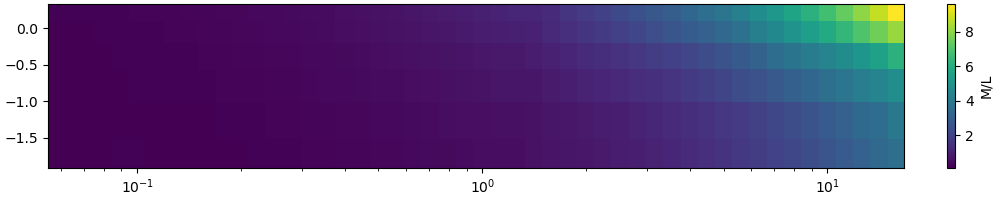

In [114]:
fig, ax = plt.subplots(figsize=(10, 2), constrained_layout=True)
im = ax.pcolor(age_range_ml, mh_range_ml, grid)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('M/L')
ax.set_xscale('log')


# print(age_range.shape) 
# print(mh_range_ml.shape)
# print(grid.shape)

In [107]:
wm = w[:, :, 0] * grid.T
fig, ax = plt.subplots(figsize=(10,2), constrained_layout=True)
ax.pcolor(age_range_ml, mh_range_ml, wm.T)

# print(age_range_ml.shape) 
# print(mh_range_ml.shape)
# print(wm.T.shape)

ValueError: Unable to coerce to DataFrame, shape must be (48, 6): given (25, 6)

Text(0, 0.5, 'Cumulative Fraction')

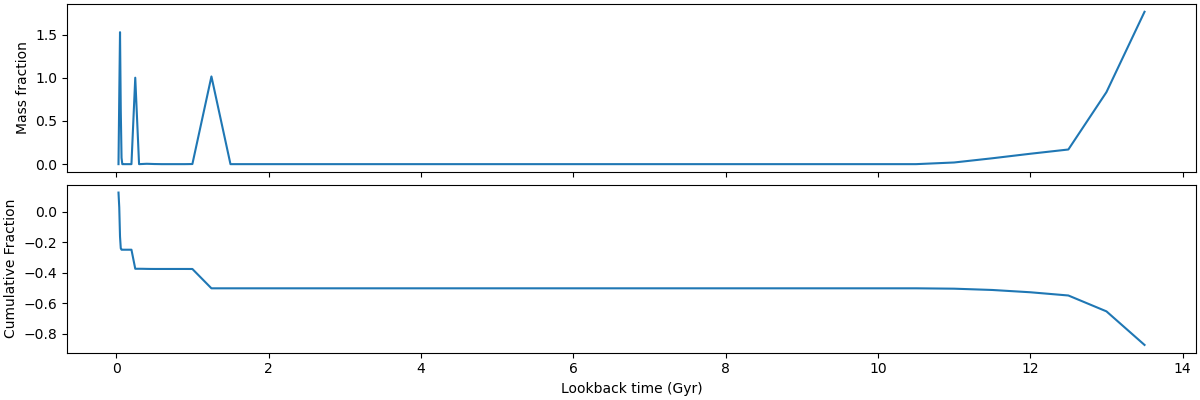

In [62]:
wm_sum_ages = np.nansum(wm/wm.sum(), 1)

fig, ax = plt.subplots(2, 1, figsize=(12,4), constrained_layout=True, sharex=True)
ax[0].plot(age_range, wm_sum_ages)
# ax[0].set_xlabel('Lookback time (Gyr)')
ax[0].set_ylabel('Mass fraction')
# ax[0].invert_xaxis()
# ax[0].set_xscale('log')

ax[1].plot(age_range, (1 - wm_sum_ages.cumsum())/wm_sum_ages.sum())
ax[1].set_xlabel('Lookback time (Gyr)')
ax[1].set_ylabel('Cumulative Fraction')
# ax[1].invert_xaxis()
# ax[1].set_xscale('log

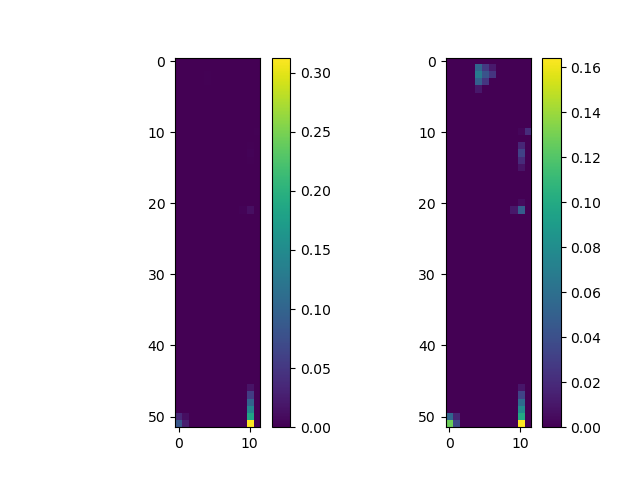

In [20]:
fig, ax = plt.subplots(1,2)
im0 = ax[0].imshow(w_m)
im1 = ax[1].imshow(w)
cbar0 = plt.colorbar(im0, ax=ax[0])
cbar1 = plt.colorbar(im1, ax=ax[1])